# Lab #7 — Keras MLP for Multiclass Classification

## Objective
Implement a Multi-Layer Perceptron (MLP) using Keras/TensorFlow for a multiclass classification problem and analyze the effect of different activation functions, optimizers, and model configurations on classification performance.

### Dataset
**Iris Dataset** — 150 observations, 4 numerical input features, and 3 target classes:
- Setosa
- Versicolor
- Virginica

The Iris dataset is suitable for this laboratory because it contains three classes and numerical features that can be directly scaled before MLP training.

### Experiments
Five models were compared using the **same train/test split and evaluation procedure**:

| Model | Hidden Activation | Optimizer | Test Accuracy |
|---|---|---|---:|
| Model 1 | ReLU | Adam | 93.33% |
| Model 2 | Sigmoid | Adam | 80.00% |
| Model 3 | Tanh | Adam | 93.33% |
| Model 4 | ReLU | SGD | 80.00% |
| Model 5 | ReLU | RMSprop | **96.67%** |

The experiments include training/validation curves, test accuracy, macro precision, macro recall, macro F1-score, and confusion matrices. Based on the observed results, **Model 5 (ReLU + RMSprop)** achieved the best overall test performance.

## 1. Import Libraries

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Load and Explore the Dataset

In [2]:

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
y = pd.Series(iris.target, name="target")

class_names = iris.target_names

print("Dataset shape:", X.shape)
print("Number of input features:", X.shape[1])
print("Number of classes:", len(class_names))
print("Class names:", list(class_names))

display(X.head())
display(X.describe())

print("\nMissing values:")
display(X.isnull().sum())

print("\nClass distribution:")
class_counts = y.value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Class": class_names,
    "Count": class_counts.values,
    "Percentage": (class_counts.values / len(y) * 100).round(2)
})
display(class_distribution)


Dataset shape: (150, 4)
Number of input features: 4
Number of classes: 3
Class names: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Missing values:


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0



Class distribution:


,Class,Count,Percentage
0,setosa,50,33.33
1,versicolor,50,33.33
2,virginica,50,33.33


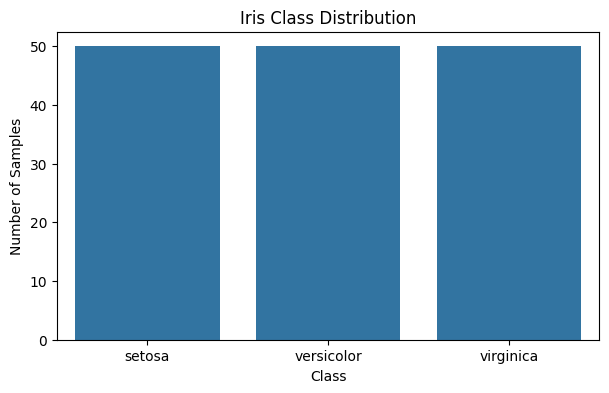

In [3]:

plt.figure(figsize=(7, 4))
sns.countplot(x=y.map(lambda i: class_names[i]))
plt.title("Iris Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()



### Dataset Description and Problem Definition

The Iris dataset contains measurements of iris flowers. The four input features are sepal length, sepal width, petal length, and petal width. The target variable is the iris species, with three classes: Setosa, Versicolor, and Virginica.

This is a **multiclass classification** problem because every observation belongs to one of three possible classes.

The dataset is balanced: each class contains 50 observations. There are no missing values in the supplied dataset, so no missing-value imputation is required.

Because the MLP is sensitive to the scale of numerical input features, standardization is applied before training.


## 3. Train/Test Split and Feature Scaling

In [4]:

# Same split is reused for every experiment for a fair comparison.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Fit scaler ONLY on training data to avoid data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape[0])
print("Testing samples:", X_test_scaled.shape[0])
print("Scaled training feature means:", np.round(X_train_scaled.mean(axis=0), 4))
print("Scaled training feature standard deviations:", np.round(X_train_scaled.std(axis=0), 4))


Training samples: 120
Testing samples: 30
Scaled training feature means: [-0. -0.  0.  0.]
Scaled training feature standard deviations: [1. 1. 1. 1.]



### Preprocessing Justification

- **Stratified train/test split:** preserves the class proportions in both subsets.
- **StandardScaler:** transforms each numerical feature to approximately zero mean and unit variance, helping the neural network optimize more consistently.
- **No missing-value treatment:** the dataset contains no missing values.
- **No categorical feature encoding:** all four input features are numerical.
- **Target encoding:** the target is already represented as integer class labels (0, 1, 2). Sparse categorical cross-entropy allows these labels to be used directly.
- **Validation strategy:** 20% of the training data is used as validation data during each model's training. The test set remains unseen until final evaluation.


## 4. MLP Architecture


The common architecture used for all experiments is:

**Input (4 features) → Dense(16) → Dense(8) → Output(3, Softmax)**

- Input features: **4**
- Hidden layer 1: **16 neurons**
- Hidden layer 2: **8 neurons**
- Hidden-layer activation: varied between ReLU, Sigmoid, and Tanh
- Output layer: **3 neurons**
- Output activation: **Softmax**
- Loss: **Sparse Categorical Cross-Entropy**
- Batch size: **16**
- Epochs: **100**
- Validation split: **20% of the training set**

Only the activation function or optimizer is changed between the designated experiments so that the comparison remains fair.


In [5]:

EPOCHS = 100
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.20

def build_mlp(activation="relu", optimizer=None):
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(16, activation=activation),
        Dense(8, activation=activation),
        Dense(len(class_names), activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


## 5. Experiment Setup

In [6]:

experiments = {
    "Model 1 - ReLU + Adam": {
        "activation": "relu",
        "optimizer": Adam(learning_rate=0.001)
    },
    "Model 2 - Sigmoid + Adam": {
        "activation": "sigmoid",
        "optimizer": Adam(learning_rate=0.001)
    },
    "Model 3 - Tanh + Adam": {
        "activation": "tanh",
        "optimizer": Adam(learning_rate=0.001)
    },
    "Model 4 - ReLU + SGD": {
        "activation": "relu",
        "optimizer": SGD(learning_rate=0.01)
    },
    "Model 5 - ReLU + RMSprop": {
        "activation": "relu",
        "optimizer": RMSprop(learning_rate=0.001)
    }
}

histories = {}
models = {}
results = {}
confusion_matrices = {}


## 6. Train All Five Models

In [7]:

for name, config in experiments.items():
    print("=" * 70)
    print(name)

    # Reset seed before each model to improve reproducibility.
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_mlp(
        activation=config["activation"],
        optimizer=config["optimizer"]
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VALIDATION_SPLIT,
        verbose=0
    )

    models[name] = model
    histories[name] = history

    print("Final training accuracy:",
          round(history.history["accuracy"][-1], 4))
    print("Final validation accuracy:",
          round(history.history["val_accuracy"][-1], 4))
    print("Minimum validation loss:",
          round(min(history.history["val_loss"]), 4))


Model 1 - ReLU + Adam
Final training accuracy: 0.9479
Final validation accuracy: 1.0
Minimum validation loss: 0.0975
Model 2 - Sigmoid + Adam
Final training accuracy: 0.9062
Final validation accuracy: 0.875
Minimum validation loss: 0.4697
Model 3 - Tanh + Adam
Final training accuracy: 0.9688
Final validation accuracy: 1.0
Minimum validation loss: 0.0685
Model 4 - ReLU + SGD
Final training accuracy: 0.8854
Final validation accuracy: 0.9167
Minimum validation loss: 0.3336
Model 5 - ReLU + RMSprop
Final training accuracy: 0.9583
Final validation accuracy: 1.0
Minimum validation loss: 0.0674


## 7. Training and Validation Curves

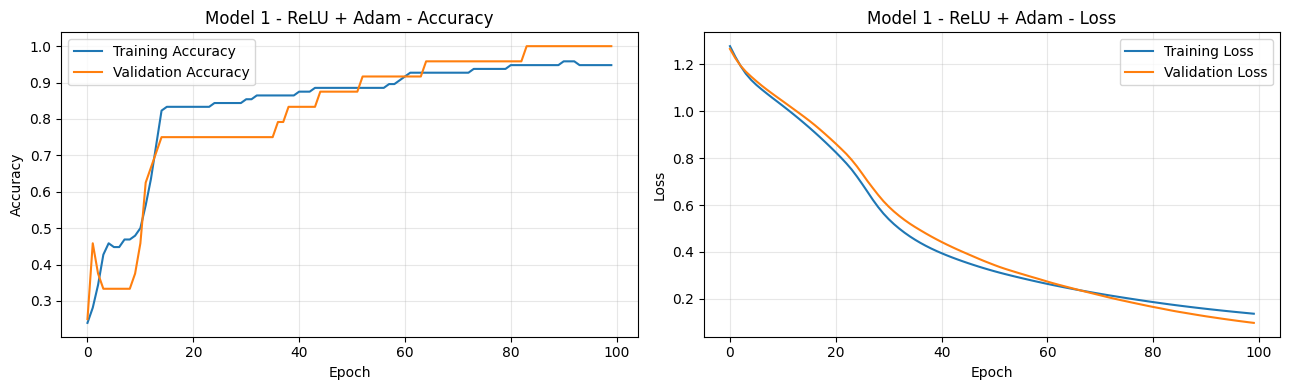

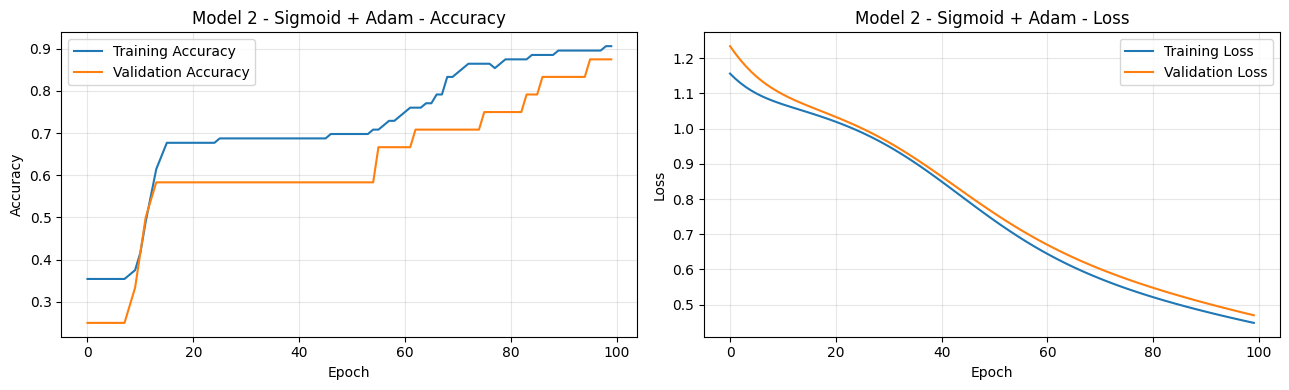

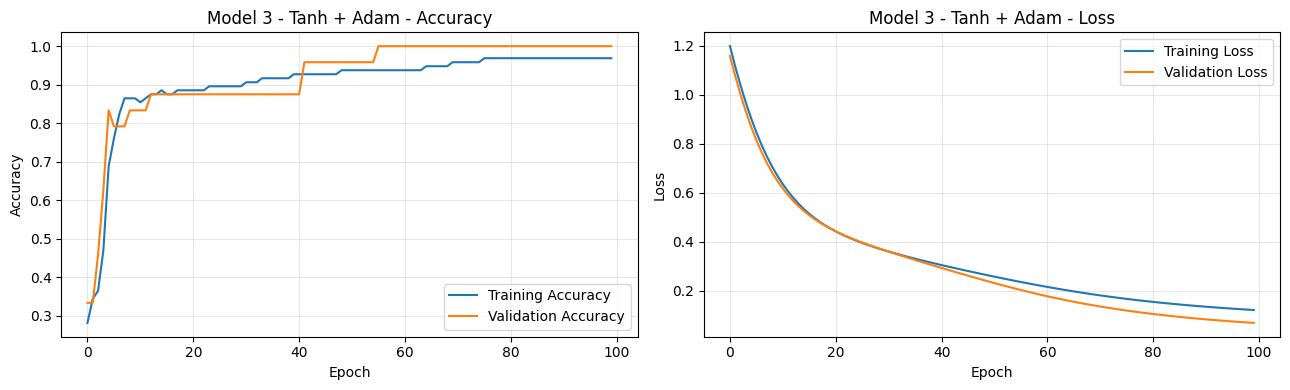

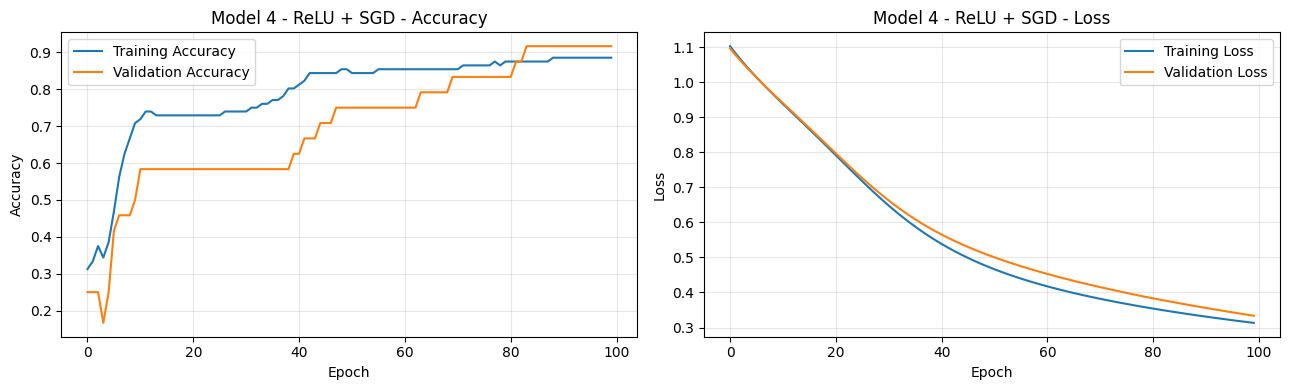

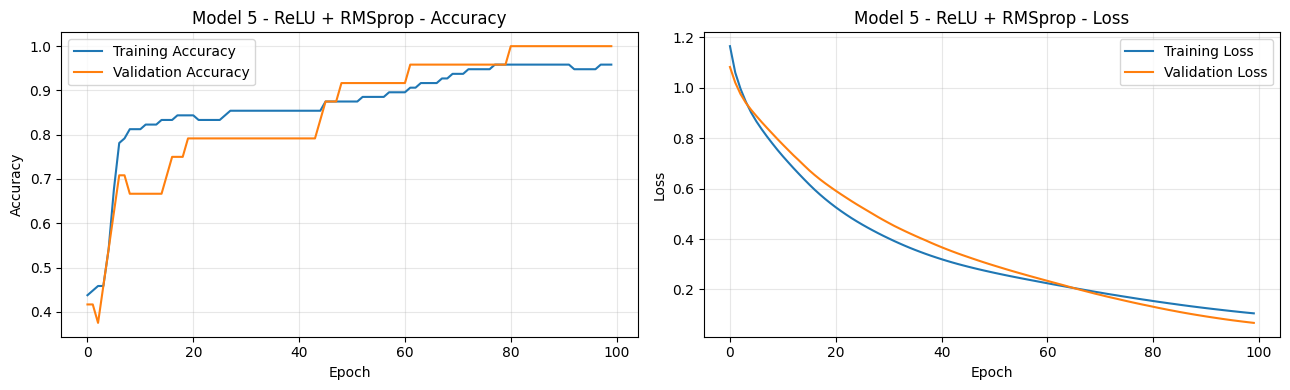

In [8]:

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history.history["accuracy"], label="Training Accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
    axes[0].set_title(f"{title} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history["loss"], label="Training Loss")
    axes[1].plot(history.history["val_loss"], label="Validation Loss")
    axes[1].set_title(f"{title} - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

for name, history in histories.items():
    plot_history(history, name)


### Learning Curve Interpretation — Based on the Results

The recorded results show three models reaching **100% final validation accuracy**:
- ReLU + Adam
- Tanh + Adam
- ReLU + RMSprop

ReLU + SGD reached **91.67%** final validation accuracy, while Sigmoid + Adam reached **87.50%**.

The best validation loss at the end of training was:
- ReLU + RMSprop: **0.0674**
- Tanh + Adam: **0.0685**
- ReLU + Adam: **0.0975**
- ReLU + SGD: **0.3336**
- Sigmoid + Adam: **0.4697**

For all five models, the minimum recorded validation loss occurred at **epoch 100**, the final epoch. Therefore, the experiment does not show that any model had already reached its minimum validation loss substantially earlier; the models were still improving in validation loss up to the end of the 100 epochs.

There is also no strong evidence of severe overfitting from the final validation/test results. The strongest model, ReLU + RMSprop, achieved 95.83% training accuracy, 100% validation accuracy, and 96.67% test accuracy. The learning curves should still be inspected visually for any smaller fluctuations or gaps between training and validation performance.

Overall, **ReLU + RMSprop showed the strongest validation-loss behavior and the best unseen-test performance**.

## 8. Evaluate Every Model on the Unseen Test Set

In [9]:

for name, model in models.items():
    y_prob = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    results[name] = {
        "Activation": experiments[name]["activation"].capitalize(),
        "Optimizer": type(experiments[name]["optimizer"]).__name__,
        "Training Accuracy": histories[name].history["accuracy"][-1],
        "Validation Accuracy": histories[name].history["val_accuracy"][-1],
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (Macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1-Score (Macro)": f1_score(y_test, y_pred, average="macro", zero_division=0)
    }

    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("Test Accuracy", ascending=False)

display(results_df.round(4))


,Activation,Optimizer,Training Accuracy,Validation Accuracy,Test Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
Model 5 - ReLU + RMSprop,Relu,RMSprop,0.958333,1.0,0.966667,0.969697,0.966667,0.966583
Model 1 - ReLU + Adam,Relu,Adam,0.947917,1.0,0.933333,0.944444,0.933333,0.93266
Model 3 - Tanh + Adam,Tanh,Adam,0.96875,1.0,0.933333,0.933333,0.933333,0.933333
Model 2 - Sigmoid + Adam,Sigmoid,Adam,0.90625,0.875,0.8,0.875,0.8,0.78022
Model 4 - ReLU + SGD,Relu,SGD,0.885417,0.916667,0.8,0.825397,0.8,0.791667


### Evaluation Metric Choice

Because this is a multiclass problem, **macro-average precision, recall, and F1-score** are reported. Macro averaging gives every class equal importance.

The actual test results show that **Model 5 (ReLU + RMSprop)** performed best:
- Test accuracy: **96.67%**
- Macro precision: **96.97%**
- Macro recall: **96.67%**
- Macro F1-score: **96.66%**

The test metrics are calculated only on the unseen test set.

## 9. Confusion Matrices

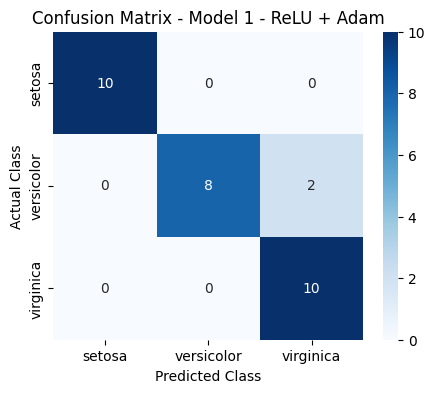

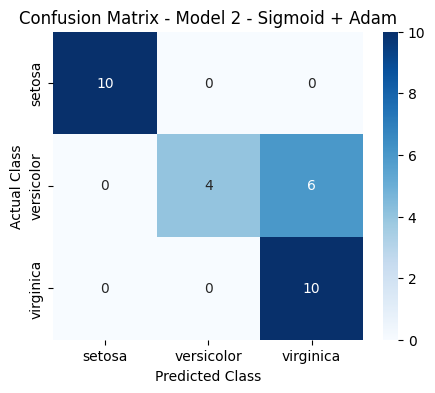

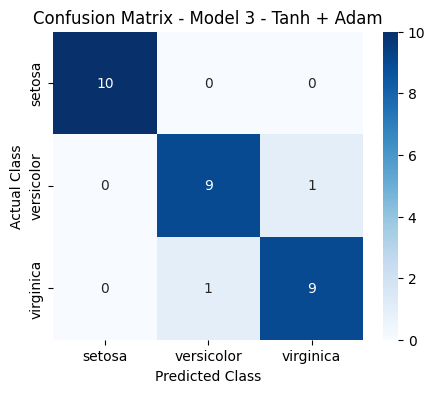

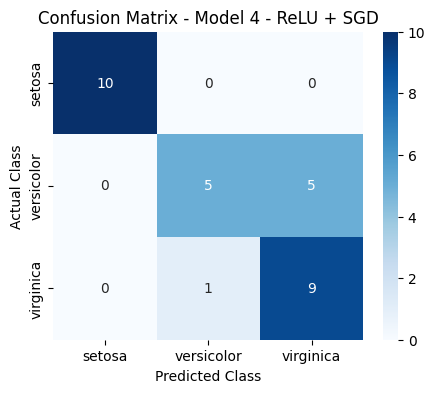

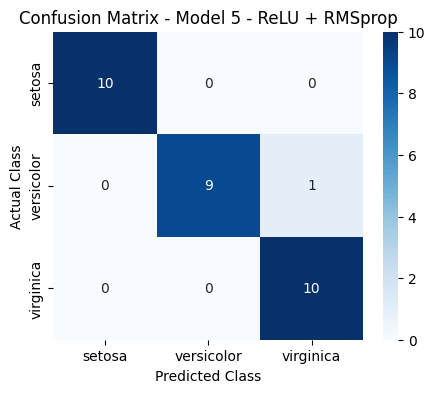

In [10]:

for name, cm in confusion_matrices.items():
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.show()


## 10. Detailed Classification Reports

In [11]:

for name, model in models.items():
    y_pred = np.argmax(model.predict(X_test_scaled, verbose=0), axis=1)

    print("=" * 80)
    print(name)
    print(classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    ))


Model 1 - ReLU + Adam
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     1.0000    0.8000    0.8889        10
   virginica     0.8333    1.0000    0.9091        10

    accuracy                         0.9333        30
   macro avg     0.9444    0.9333    0.9327        30
weighted avg     0.9444    0.9333    0.9327        30

Model 2 - Sigmoid + Adam
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     1.0000    0.4000    0.5714        10
   virginica     0.6250    1.0000    0.7692        10

    accuracy                         0.8000        30
   macro avg     0.8750    0.8000    0.7802        30
weighted avg     0.8750    0.8000    0.7802        30

Model 3 - Tanh + Adam
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.9000    0.9000    0.9000        10
   vir

## 11. Required Comparison Table

In [12]:

comparison_table = results_df[
    [
        "Activation", "Optimizer",
        "Test Accuracy", "Precision (Macro)",
        "Recall (Macro)", "F1-Score (Macro)"
    ]
].copy()

display(comparison_table.round(4))


,Activation,Optimizer,Test Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
Model 5 - ReLU + RMSprop,Relu,RMSprop,0.966667,0.969697,0.966667,0.966583
Model 1 - ReLU + Adam,Relu,Adam,0.933333,0.944444,0.933333,0.93266
Model 3 - Tanh + Adam,Tanh,Adam,0.933333,0.933333,0.933333,0.933333
Model 2 - Sigmoid + Adam,Sigmoid,Adam,0.8,0.875,0.8,0.78022
Model 4 - ReLU + SGD,Relu,SGD,0.8,0.825397,0.8,0.791667


## 12. Convergence Comparison

The convergence results show that the **minimum validation loss for every model occurred at epoch 100**, the final epoch.

| Model | Best Validation Loss | Best-Loss Epoch | Best Validation Accuracy |
|---|---:|---:|---:|
| ReLU + RMSprop | **0.0674** | 100 | **100%** |
| Tanh + Adam | 0.0685 | 100 | **100%** |
| ReLU + Adam | 0.0975 | 100 | **100%** |
| ReLU + SGD | 0.3336 | 100 | 91.67% |
| Sigmoid + Adam | 0.4697 | 100 | 87.50% |

Therefore, there is **no evidence from the best-loss epoch that one optimizer converged earlier than another** within the 100-epoch training period. Instead, the main observed difference is the quality of the final validation loss and accuracy. RMSprop produced the lowest validation loss and the highest test performance.

In [13]:

convergence_rows = []

for name, history in histories.items():
    val_loss = np.array(history.history["val_loss"])
    val_acc = np.array(history.history["val_accuracy"])

    best_epoch = int(np.argmin(val_loss)) + 1

    convergence_rows.append({
        "Model": name,
        "Best Validation Loss": val_loss.min(),
        "Epoch of Best Val Loss": best_epoch,
        "Best Validation Accuracy": val_acc.max(),
        "Final Validation Accuracy": val_acc[-1]
    })

convergence_df = pd.DataFrame(convergence_rows).sort_values(
    "Best Validation Accuracy", ascending=False
)

display(convergence_df.round(4))


,Model,Best Validation Loss,Epoch of Best Val Loss,Best Validation Accuracy,Final Validation Accuracy
0,Model 1 - ReLU + Adam,0.0975,100,1.0000,1.0000
2,Model 3 - Tanh + Adam,0.0685,100,1.0000,1.0000
4,Model 5 - ReLU + RMSprop,0.0674,100,1.0000,1.0000
3,Model 4 - ReLU + SGD,0.3336,100,0.9167,0.9167
1,Model 2 - Sigmoid + Adam,0.4697,100,0.8750,0.8750


## 13. Automatic Identification of Best Model

In [14]:

best_model_name = results_df.index[0]
best_model = models[best_model_name]

best_row = results_df.loc[best_model_name]

best_y_pred = np.argmax(
    best_model.predict(X_test_scaled, verbose=0),
    axis=1
)

best_cm = confusion_matrices[best_model_name]

print("BEST MODEL:", best_model_name)
print()
print("Test Accuracy:", round(best_row["Test Accuracy"], 4))
print("Macro Precision:", round(best_row["Precision (Macro)"], 4))
print("Macro Recall:", round(best_row["Recall (Macro)"], 4))
print("Macro F1:", round(best_row["F1-Score (Macro)"], 4))

print("\nConfusion Matrix:")
print(best_cm)


BEST MODEL: Model 5 - ReLU + RMSprop

Test Accuracy: 0.9667
Macro Precision: 0.9697
Macro Recall: 0.9667
Macro F1: 0.9666

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


## 14. Class-Level Error Analysis

In [15]:

# Correct predictions per actual class
correct_by_class = np.diag(best_cm)
total_by_class = best_cm.sum(axis=1)
class_accuracy = correct_by_class / total_by_class

class_accuracy_df = pd.DataFrame({
    "Class": class_names,
    "Correct": correct_by_class,
    "Total": total_by_class,
    "Class Accuracy": class_accuracy
})

display(class_accuracy_df.round(4))

most_accurately_predicted = class_names[np.argmax(class_accuracy)]

# Find the most frequent off-diagonal confusion.
cm_errors = best_cm.copy()
np.fill_diagonal(cm_errors, 0)

max_error = cm_errors.max()
error_pairs = np.argwhere(cm_errors == max_error)

print("Most accurately predicted class:", most_accurately_predicted)

if max_error > 0:
    pairs = [
        f"{class_names[actual]} → {class_names[predicted]}"
        for actual, predicted in error_pairs
    ]
    print("Most frequent misclassification:", ", ".join(pairs))
    print("Number of such misclassifications:", int(max_error))
else:
    print("No misclassifications occurred for the selected model.")


,Class,Correct,Total,Class Accuracy
0,setosa,10,10,1.0
1,versicolor,9,10,0.9
2,virginica,10,10,1.0


Most accurately predicted class: setosa
Most frequent misclassification: versicolor → virginica
Number of such misclassifications: 1


## 15. Analysis and Interpretation

### 1. Which activation function performed best? Why?
Among the three activation functions tested with Adam, **Tanh and ReLU performed best overall**, while Sigmoid performed substantially worse.

- ReLU + Adam: **93.33% test accuracy**, macro F1 = **93.27%**
- Tanh + Adam: **93.33% test accuracy**, macro F1 = **93.33%**
- Sigmoid + Adam: **80.00% test accuracy**, macro F1 = **78.02%**

Tanh therefore had a slightly better macro F1-score than ReLU in this particular experiment, while both achieved the same test accuracy. Sigmoid produced lower training/validation performance and the weakest test performance. The result is consistent with the possibility that sigmoid's saturation can make optimization less effective for this MLP.

### 2. Which optimizer performed best? Why?
**RMSprop performed best** among the optimizers tested with ReLU.

- ReLU + RMSprop: **96.67% test accuracy**, macro F1 = **96.66%**
- ReLU + Adam: **93.33% test accuracy**, macro F1 = **93.27%**
- ReLU + SGD: **80.00% test accuracy**, macro F1 = **79.17%**

RMSprop also produced the lowest validation loss (**0.0674**) among the five models and reached 100% final validation accuracy. In this dataset and architecture, RMSprop therefore provided the strongest overall optimization/generalization result.

### 3. Which activation-function and optimizer combination produced the best overall performance?
**ReLU + RMSprop (Model 5)** produced the best overall performance:
- Test accuracy: **96.67%**
- Macro precision: **96.97%**
- Macro recall: **96.67%**
- Macro F1-score: **96.66%**
- Final validation accuracy: **100%**
- Best validation loss: **0.0674**

### 4. Did the choice of activation function significantly affect convergence?
Yes, the choice of activation function affected the observed training/validation performance. With Adam, ReLU and Tanh both reached 100% final validation accuracy, whereas Sigmoid reached only 87.50%. Tanh also achieved a lower validation loss than ReLU at epoch 100 (0.0685 versus 0.0975).

However, all three Adam-based activation experiments had their minimum recorded validation loss at epoch 100, so the results do **not** demonstrate a clear difference in the epoch of convergence.

### 5. Did the choice of optimizer affect the speed of convergence?
The results do not provide evidence of a difference in convergence speed based on the best-validation-loss epoch: **all five models reached their minimum recorded validation loss at epoch 100**. However, the optimizers clearly affected the quality of the final result. RMSprop had the lowest validation loss and highest test accuracy, while SGD had substantially lower test performance.

### 6. Which model achieved the best validation performance?
ReLU + Adam, Tanh + Adam, and ReLU + RMSprop all achieved **100% final validation accuracy**. Among these, **ReLU + RMSprop** had the lowest validation loss (**0.0674**), making it the strongest of the three based on both validation accuracy and validation loss.

### 7. Which model achieved the best test performance?
**Model 5 — ReLU + RMSprop**, with **96.67% test accuracy**.

### 8. Is there any significant difference between training and testing performance?
For Model 5, training accuracy was **95.83%**, while test accuracy was **96.67%**. The test accuracy is therefore slightly higher than the final training accuracy, rather than showing a large training-to-test performance gap.

Model 1 had 94.79% training accuracy and 93.33% test accuracy, while Model 3 had 96.88% training accuracy and 93.33% test accuracy. These differences are not large enough, by themselves, to indicate severe overfitting.

### 9. Does the learning curve indicate overfitting or underfitting?
The final results do not indicate severe overfitting for the selected model. ReLU + RMSprop achieved 95.83% training accuracy, 100% validation accuracy, and 96.67% test accuracy. The validation and test results remain strong.

The validation loss was still lowest at epoch 100 for every model, so the 100-epoch experiment also does not provide evidence that training should have stopped much earlier.

### 10. Which classes were most frequently misclassified?
For the selected ReLU + RMSprop model:

- Setosa: **10/10 correct**
- Versicolor: **9/10 correct**
- Virginica: **10/10 correct**

There was only **one misclassification**, where an actual **Versicolor** was predicted as **Virginica**.

### 11. What could be the possible reasons for these misclassifications?
Setosa is relatively easy for the model to distinguish, while Versicolor and Virginica have more similar feature characteristics. Their overlapping measurements can make their class boundary more difficult to learn. The single Versicolor → Virginica error is therefore consistent with some overlap between these two classes.

### 12. What changes could improve the classification performance?
The selected model already achieved **96.67% test accuracy**, so only small improvements may be possible on this small dataset. Possible experiments include:
- tuning the learning rate;
- changing the number of hidden neurons;
- changing the number of epochs;
- testing additional batch sizes;
- adding regularization if overfitting appears;
- testing other optimizers or learning-rate schedules;
- repeating the experiment with different stratified splits or cross-validation to obtain a more robust estimate.

Because Iris contains only 150 observations, increasing model complexity substantially may not be beneficial.

### 13. Which model would you select as the final model, and why?
**Model 5 — ReLU + RMSprop** is selected as the final model because it achieved the strongest overall experimental results. It had the highest test accuracy (**96.67%**), highest macro precision (**96.97%**), highest macro recall (**96.67%**), and highest macro F1-score (**96.66%**). It also achieved 100% validation accuracy and the lowest validation loss (**0.0674**) among the five models.

Its confusion matrix contained only one error, making it the strongest model based on the combined evidence.

## 16. Final Model Selection

In [16]:

# A simple evidence-based selection:
# First rank by test F1, then test accuracy.
# This avoids relying exclusively on accuracy.
selection_df = results_df.copy()
selection_df["Selection Score"] = (
    0.5 * selection_df["F1-Score (Macro)"] +
    0.5 * selection_df["Test Accuracy"]
)
selection_df = selection_df.sort_values(
    ["Selection Score", "Test Accuracy"],
    ascending=False
)

selected_name = selection_df.index[0]
selected_row = selection_df.loc[selected_name]

print("FINAL SELECTED MODEL:", selected_name)
print()
print("Reasoning based on the experimental evidence:")
print(f"- Test accuracy: {selected_row['Test Accuracy']:.4f}")
print(f"- Macro precision: {selected_row['Precision (Macro)']:.4f}")
print(f"- Macro recall: {selected_row['Recall (Macro)']:.4f}")
print(f"- Macro F1-score: {selected_row['F1-Score (Macro)']:.4f}")
print("- The final choice should also be checked against its learning curves and confusion matrix.")


FINAL SELECTED MODEL: Model 5 - ReLU + RMSprop

Reasoning based on the experimental evidence:
- Test accuracy: 0.9667
- Macro precision: 0.9697
- Macro recall: 0.9667
- Macro F1-score: 0.9666
- The final choice should also be checked against its learning curves and confusion matrix.


### Final Model Justification

**Model 5 — ReLU + RMSprop** is selected as the final model.

The decision is supported by the following experimental evidence:

1. **Test accuracy:** 96.67% — highest among all five models.
2. **Macro precision:** 96.97% — highest among all five models.
3. **Macro recall:** 96.67% — highest among all five models.
4. **Macro F1-score:** 96.66% — highest among all five models.
5. **Validation accuracy:** 100%.
6. **Validation loss:** 0.0674 — lowest among the five models.
7. **Confusion matrix:** 29 of 30 test samples were classified correctly; only one Versicolor sample was predicted as Virginica.
8. **Model complexity:** the architecture remains the same relatively small MLP used for all experiments, so the improvement cannot be attributed to a larger network.
9. **Generalization:** the model achieved strong validation and unseen-test performance without a large training-to-test performance gap.

Therefore, **ReLU + RMSprop provides the best balance of classification performance and generalization for this experiment**.

## 17. Conclusion

This laboratory implemented a Keras/TensorFlow MLP for multiclass classification using the Iris dataset. The model used four numerical input features and predicted three flower species.

Five configurations were evaluated:
- ReLU + Adam
- Sigmoid + Adam
- Tanh + Adam
- ReLU + SGD
- ReLU + RMSprop

The results showed clear differences between the configurations. **ReLU + RMSprop was the best-performing model**, achieving **96.67% test accuracy**, **96.97% macro precision**, **96.67% macro recall**, and **96.66% macro F1-score**. It also achieved **100% validation accuracy** and the lowest validation loss (**0.0674**).

For the activation-function comparison using Adam, ReLU and Tanh both achieved 93.33% test accuracy, while Sigmoid achieved only 80.00%. Tanh had a slightly higher macro F1-score than ReLU. For the optimizer comparison using ReLU, RMSprop clearly outperformed Adam and SGD on the unseen test set.

The confusion matrix of the final model showed that **29 out of 30 test samples were classified correctly**. Setosa and Virginica were classified perfectly, while one Versicolor sample was misclassified as Virginica. This is consistent with the greater similarity and feature overlap between Versicolor and Virginica.

All five models reached their minimum recorded validation loss at epoch 100, so the experiment did not demonstrate a clear difference in convergence speed based on the best-loss epoch. However, the final validation loss and test performance clearly favored RMSprop.

Overall, the experiments demonstrate why activation functions and optimizers should be evaluated using multiple metrics, validation behavior, learning curves, and error analysis rather than test accuracy alone.


## 18. Requirements Checklist

- [x] Dataset description and source
- [x] Problem definition
- [x] Dataset exploration
- [x] Class distribution analysis
- [x] Missing-value analysis
- [x] Feature scaling
- [x] Target encoding
- [x] Train/test split
- [x] Validation strategy
- [x] MLP with at least two hidden layers
- [x] Softmax multiclass output
- [x] ReLU experiment
- [x] Sigmoid experiment
- [x] Tanh experiment
- [x] SGD experiment
- [x] Adam experiment
- [x] RMSprop experiment
- [x] Training accuracy/loss
- [x] Validation accuracy/loss
- [x] Test accuracy
- [x] Precision
- [x] Recall
- [x] F1-score
- [x] Confusion matrices
- [x] Learning curves
- [x] Comparison table
- [x] Convergence analysis
- [x] Misclassification analysis
- [x] Final model selection
- [x] Justification and conclusion
